In [32]:
import pandas as pd 

# csv_file = "intervalos vazao  esmond data psmp-gn-bw-lis-pt.geant.org to perfsonar-ankara.ulakbim.gov.tr 10-24-2023.csv"
csv_file = "intervalos vazao  esmond data psmp-gn-bw-poz-pl.geant.org to pspmp-anella.csuc.cat 10-24-2023.csv"
df = pd.read_csv(csv_file)
df.head()

,Data,Intervalo,Vazao
0,27-4-2023,00:00:00 a 05:59:59,-1.0
1,27-4-2023,06:00:00 a 11:59:59,-1.0
2,27-4-2023,12:00:00 a 17:59:59,-1.0
3,27-4-2023,18:00:00 a 23:59:59,885524468.0
4,28-4-2023,00:00:00 a 05:59:59,835191924.5


Clean date and interval columns to use as timestamp

In [33]:
# Split start ("Inicio") and end ("Fim") times from interval column
df[["Inicio", "Fim"]] = df["Intervalo"].str.split(" a ", expand=True)

# Convert date and start time to datetime to create a timestamp
df["timestamp"] = pd.to_datetime(    (df["Data"].str.strip() + " " + df["Inicio"].str.strip()) , dayfirst=True, format="%d-%m-%Y %H:%M:%S")
# df["timestamp_fim"] = pd.to_datetime(df["Data"] + " " + df["Fim"], dayfirst=True)

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.drop(columns=["Intervalo", "Data", "Inicio", "Fim"])
df.head()

,Vazao,timestamp
0,-1.0,2023-04-27 00:00:00
1,-1.0,2023-04-27 06:00:00
2,-1.0,2023-04-27 12:00:00
3,885524468.0,2023-04-27 18:00:00
4,835191924.5,2023-04-28 00:00:00


Split manually choosen longest interval

In [34]:
# start = "2023-06-01 12:00:00"
# end    = "2023-07-17 00:00:00"

start = "2023-06-04 12:00:00"
end    = "2023-07-21 00:00:00"

longest_interval = df[(df["timestamp"] >= start) & (df["timestamp"] <= end)]

longest_interval.shape

(187, 2)

In [35]:
import numpy as np

longest_interval["Vazao"] = longest_interval["Vazao"].replace(-1, np.nan)

longest_interval["Vazao"] = longest_interval["Vazao"].interpolate(method="linear")
print(longest_interval.isna().sum())
longest_interval.head(20)

Vazao        0
timestamp    0
dtype: int64


/tmp/ipykernel_15331/834657600.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  longest_interval["Vazao"] = longest_interval["Vazao"].replace(-1, np.nan)
/tmp/ipykernel_15331/834657600.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  longest_interval["Vazao"] = longest_interval["Vazao"].interpolate(method="linear")


,Vazao,timestamp
126,8.704948e+08,2023-06-04 12:00:00
127,7.877440e+08,2023-06-04 18:00:00
128,8.199872e+08,2023-06-05 00:00:00
129,8.776594e+08,2023-06-05 06:00:00
130,9.054506e+08,2023-06-05 12:00:00
131,8.800193e+08,2023-06-05 18:00:00
132,7.895792e+08,2023-06-06 00:00:00
133,7.444916e+08,2023-06-06 06:00:00
134,7.355779e+08,2023-06-06 12:00:00
135,8.401734e+08,2023-06-06 18:00:00


In [36]:
missing_rates = [0.1, 0.2, 0.3, 0.4]
random_seed = 42
missing_longest = longest_interval.copy()

missing_dfs = {}
for missing_rate in missing_rates:
    missing_idx = missing_longest.sample(
        frac=missing_rate,
        random_state=random_seed
    ).index
    missing_longest.loc[missing_idx, "Vazao"] = -1
    missing_dfs[missing_rate] = missing_longest

missing_dfs[0.1].head(20)

,Vazao,timestamp
126,8.704948e+08,2023-06-04 12:00:00
127,7.877440e+08,2023-06-04 18:00:00
128,-1.000000e+00,2023-06-05 00:00:00
129,8.776594e+08,2023-06-05 06:00:00
130,9.054506e+08,2023-06-05 12:00:00
131,-1.000000e+00,2023-06-05 18:00:00
132,7.895792e+08,2023-06-06 00:00:00
133,7.444916e+08,2023-06-06 06:00:00
134,7.355779e+08,2023-06-06 12:00:00
135,-1.000000e+00,2023-06-06 18:00:00


In [37]:
import matplotlib.pyplot as plt
import os

def visualize_time_series(df: pd.DataFrame, value_col: str, figdir: str = "."):
    fig, ax = plt.subplots(figsize=(12, 4))
    # linha base (com NaN vai quebrar)
    ax.plot(df["timestamp"], df[value_col], lw=1.5)
    # marca NaN
    nan_mask = df[value_col].isna()
    ax.scatter(df.loc[nan_mask, "timestamp"], [np.nan] * nan_mask.sum(), s=0)  # placeholder
    ax.set_title("Série temporal (com faltantes)")
    ax.set_xlabel("Tempo")
    ax.set_ylabel(value_col)
    ax.grid(True, alpha=0.3)
    # out = os.path.join(figdir, "01_serie_temporal.png")
    fig.tight_layout()
    # fig.savefig(out, dpi=160)
    # plt.close(fig)
    plt.show()


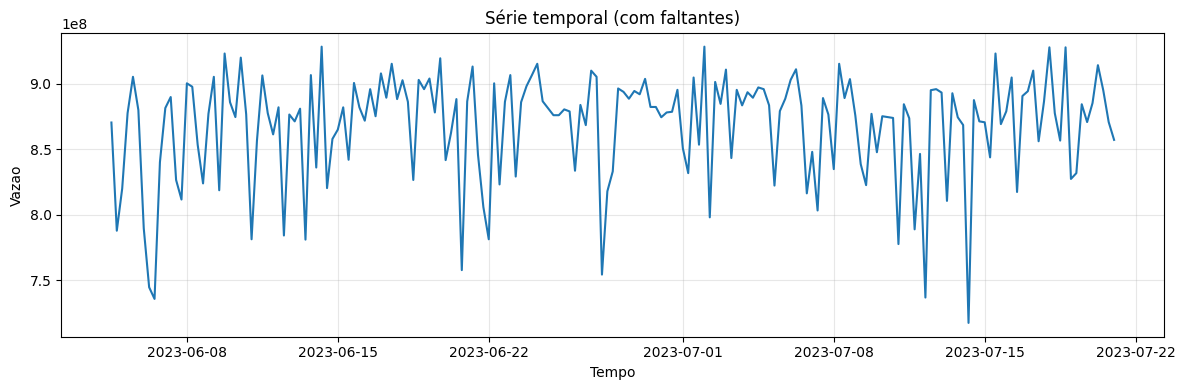

In [38]:
visualize_time_series(longest_interval, value_col="Vazao")

/tmp/ipykernel_15331/1042893459.py:23: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_filled = y_series.interpolate(limit_direction="both").fillna(method='bfill').fillna(method='ffill').to_numpy()


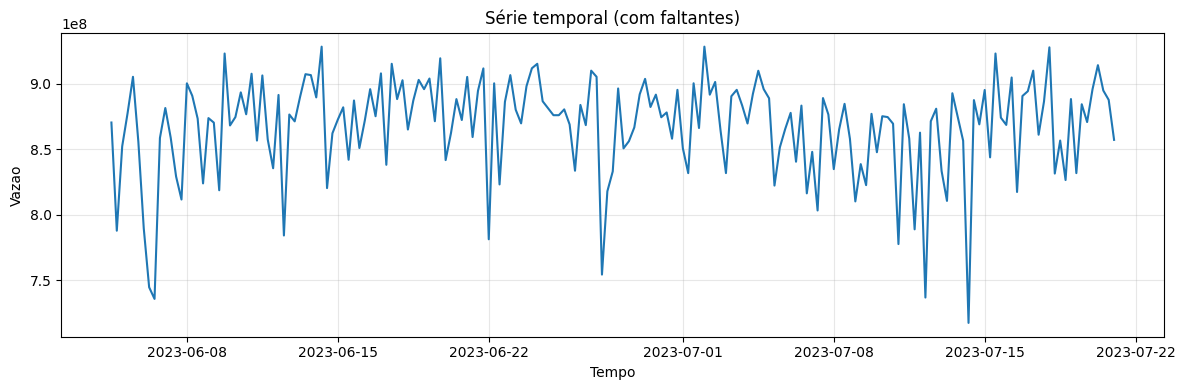

In [39]:
import pandas as pd 
import numpy as np 
from scipy import signal

def estimate_period_fft(y, min_period, max_period):
    """
    Estimate period using FFT spectral analysis.
    Finds the dominant frequency in the valid range [min_period, max_period].
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    
    # Set sensible max_period if not provided
    if max_period is None:
        max_period = max(7, min(n // 4, 1000))
    
    # Data too short for analysis
    if n < min_period * 2:
        return max(min_period, min(n, 8))
    
    # Handle missing values by interpolation #### this part can be changed if I use the unprocessed data
    y_series = pd.Series(y)
    y_filled = y_series.interpolate(limit_direction="both").fillna(method='bfill').fillna(method='ffill').to_numpy()
    
    # Handle constant series
    if np.std(y_filled) < 1e-10:
        return min_period
    
    # Detrend and normalize
    y_detrended = signal.detrend(y_filled)
    y_normalized = (y_detrended - np.mean(y_detrended)) / (np.std(y_detrended) + 1e-10)
    
    # Compute FFT
    fft_vals = np.fft.rfft(y_normalized)
    power_spectrum = np.abs(fft_vals) ** 2
    frequencies = np.fft.rfftfreq(n)
    
    # Convert frequencies to periods
    # Avoid division by zero for DC component
    with np.errstate(divide='ignore', invalid='ignore'):
        periods = 1.0 / frequencies
        periods[0] = np.inf  # DC component has infinite period
    
    # Filter to valid period range
    valid_mask = (periods >= min_period) & (periods <= max_period)
    
    if not np.any(valid_mask):
        return min_period
    
    # Find period with maximum power ####!!!!
    valid_power = power_spectrum[valid_mask]
    valid_periods = periods[valid_mask]
    
    best_period = valid_periods[np.argmax(valid_power)]
    
    return int(np.round(best_period))

def fold_series_to_matrix(y, period):
    """
    Fold 1D series into a (n_blocks, period) matrix. 
    Pads the last block with NaN if needed.
    Returns (M, original_len).
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    n_blocks = int(np.ceil(n / period))
    pad_len = n_blocks * period - n
    
    if pad_len > 0:
        y = np.concatenate([y, np.full(pad_len, np.nan)])
    
    M = y.reshape(n_blocks, period)
    return M, n

def unfold_matrix_to_series(M, original_len):
    """Inverse of fold: row-wise flatten and trim to original length."""
    y = M.reshape(-1)
    return y[:original_len]

def svd_rank(M_filled, energy=0.9):
    """
    Compute SVD and choose rank r by cumulative explained energy.
    Energy is defined as cumulative sum of singular values.
    """
    U, s, Vt = np.linalg.svd(M_filled, full_matrices=False)
    
    total_energy = np.sum(s)
    if total_energy < 1e-12:
        return U, s, Vt, 1
    
    cum_energy = np.cumsum(s) / total_energy
    r = int(np.searchsorted(cum_energy, energy) + 1)
    r = max(1, min(r, min(M_filled.shape)))
    
    return U, s, Vt, r

def _initial_fill(M):
    """
    Column-wise median fill for initial SVD computation.
    Uses global median as fallback for all-NaN columns.
    """
    M_filled = M.copy()
    
    # Compute column medians
    col_medians = np.nanmedian(M_filled, axis=0)
    
    # Fallback to global median for all-NaN columns
    global_median = np.nanmedian(M_filled)
    if np.isnan(global_median):
        global_median = 0.0
    
    col_medians = np.where(np.isnan(col_medians), global_median, col_medians)
    
    # Fill missing values
    nan_indices = np.where(np.isnan(M_filled))
    M_filled[nan_indices] = np.take(col_medians, nan_indices[1])
    
    return M_filled

def knn_in_latent(M, k=5, energy=0.9, allow_future=True):
    """
    Impute NaNs in M by KNN in SVD latent space.
    
    For each missing cell (i,j):
    - Find k nearest rows to row i in latent space
    - Use only rows where column j is observed
    - Optionally restrict to past rows only (allow_future=False)
    - Weighted average by inverse distance
    """
    # Initial fill for SVD
    M_filled = _initial_fill(M)
    
    # Compute SVD and get row embeddings
    U, s, Vt, r = svd_rank(M_filled, energy=energy)
    Z = U[:, :r] * s[:r]  # Row embeddings in latent space
    
    M_imputed = M.copy()
    T, P = M.shape
    observed_mask = ~np.isnan(M)
    
    for i in range(T):
        # Find missing columns in this row
        missing_cols = np.where(~observed_mask[i])[0]
        if len(missing_cols) == 0:
            continue
        
        zi = Z[i]
        
        # Define candidate rows for neighbors
        if allow_future:
            candidates = np.arange(T)
        else:
            candidates = np.arange(0, i)
            # If no past data available, use all rows
            if len(candidates) == 0:
                candidates = np.arange(T)
        
        for j in missing_cols:
            # Filter candidates to those with observed value in column j
            valid_candidates = candidates[observed_mask[candidates, j]]
            
            if len(valid_candidates) == 0:
                # No observed values available, keep initial fill
                continue
            
            # Compute distances in latent space
            distances = np.linalg.norm(Z[valid_candidates] - zi[None, :], axis=1)
            distances = distances + 1e-8  # Avoid division by zero
            
            # Select k nearest neighbors
            if len(distances) > k:
                nearest_indices = np.argpartition(distances, k)[:k]
                neighbor_rows = valid_candidates[nearest_indices]
                neighbor_distances = distances[nearest_indices]
            else:
                neighbor_rows = valid_candidates
                neighbor_distances = distances
            
            # Compute weighted average
            weights = 1.0 / neighbor_distances
            values = M[neighbor_rows, j]
            
            valid_mask = ~np.isnan(values)
            
            values = values[valid_mask]
            weights = weights[valid_mask]
            
            M_imputed[i, j] = np.sum(weights * values) / np.sum(weights)
    
    return M_imputed

def impute_throughput_svd_knn(df, col="throughput_bps", min_period=4, max_period=None, 
                               energy=0.9, k=5, allow_future=True):
    """
    Full SVD-KNN imputation pipeline with FFT-based period detection:
    
    1) Detect period using FFT spectral analysis
    2) Fold series into (n_blocks, period) matrix
    3) Compute SVD to get latent row embeddings
    4) Impute missing values using KNN in latent space
    5) Unfold back to original 1D series
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe
    col : str
        Column name to impute
    min_period : int
        Minimum period to consider
    max_period : int or None
        Maximum period to consider
    energy : float
        Cumulative energy threshold for SVD rank selection (0-1)
    k : int
        Number of nearest neighbors for imputation
    allow_future : bool
        Whether to use future observations as neighbors
    
    Returns:
    --------
    df_imputed : pd.DataFrame
        DataFrame with imputed values
    """
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found in DataFrame.")
    
    y = df[col].to_numpy(dtype=float) # 1D array with NaNs
    
    try:
        period = estimate_period_fft(y, min_period=min_period, max_period=max_period)
    except Exception as e:
        raise RuntimeError(f"Error in FFT period detection: {str(e)}")
    
    try:
        M, orig_len = fold_series_to_matrix(y, period=period)
    except Exception as e:
        raise RuntimeError(f"Error in folding: {str(e)}")
    
    try:
        M_imputed = knn_in_latent(M, k=k, energy=energy, allow_future=allow_future)
    except Exception as e:
        raise RuntimeError(f"Error in KNN imputation: {str(e)}")
    
    try:
        y_imputed = unfold_matrix_to_series(M_imputed, original_len=orig_len)
    except Exception as e:
        raise RuntimeError(f"Error in unfolding: {str(e)}")
    
    df_imputed = df.copy()
    df_imputed[col] = y_imputed
    
    return df_imputed

### TESTING THE FUNCTION ###
imputations = {}
df_imputed = impute_throughput_svd_knn(missing_dfs[0.1].replace(-1,np.nan), col="Vazao", min_period=4, max_period=None, energy=0.9, k=10, allow_future=True)
visualize_time_series(df_imputed, value_col="Vazao", figdir=".")

imputations["SVD_KNN"] = df_imputed

In [40]:
import pandas as pd 
import numpy as np 
from scipy import signal

def estimate_period_fft(y, min_period, max_period):
    """
    Estimate period using FFT spectral analysis.
    Finds the dominant frequency in the valid range [min_period, max_period].
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    
    if max_period is None:
        max_period = max(7, min(n // 4, 1000))
    
    if n < min_period * 2:
        return max(min_period, min(n, 8))
    
    y_series = pd.Series(y)
    y_filled = y_series.interpolate(limit_direction="both").fillna(method='bfill').fillna(method='ffill').to_numpy()
    
    if np.std(y_filled) < 1e-10:
        return min_period
    
    y_detrended = signal.detrend(y_filled)
    y_normalized = (y_detrended - np.mean(y_detrended)) / (np.std(y_detrended) + 1e-10)
    
    fft_vals = np.fft.rfft(y_normalized)
    power_spectrum = np.abs(fft_vals) ** 2
    frequencies = np.fft.rfftfreq(n)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        periods = 1.0 / frequencies
        periods[0] = np.inf
    
    valid_mask = (periods >= min_period) & (periods <= max_period)
    
    if not np.any(valid_mask):
        return min_period
    
    valid_power = power_spectrum[valid_mask]
    valid_periods = periods[valid_mask]
    
    best_period = valid_periods[np.argmax(valid_power)]
    
    return int(np.round(best_period))

def build_hankel_matrix(y, window_size):
    """
    Constrói uma matriz de Hankel a partir da série temporal.
    
    A matriz de Hankel tem a forma:
    [y[0],   y[1],   y[2],   ..., y[L-1]  ]
    [y[1],   y[2],   y[3],   ..., y[L]    ]
    [y[2],   y[3],   y[4],   ..., y[L+1]  ]
    [...                                   ]
    [y[K-1], y[K],   y[K+1], ..., y[n-1]  ]
    
    onde K = n - L + 1 (número de linhas)
          L = window_size (número de colunas)
    
    Parameters:
    -----------
    y : array-like
        Série temporal (pode conter NaNs)
    window_size : int
        Tamanho da janela (número de colunas da matriz)
    
    Returns:
    --------
    H : ndarray
        Matriz de Hankel de forma (K, L)
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    
    # Ajustar window_size se necessário
    if window_size > n:
        window_size = n
    
    K = n - window_size + 1  # número de linhas
    L = window_size          # número de colunas
    
    # Construir matriz de Hankel
    H = np.zeros((K, L))
    for i in range(K):
        H[i, :] = y[i:i+L]
    
    return H

def svd_rank(M_filled, energy=0.9):
    """
    Compute SVD and choose rank r by cumulative explained energy.
    """
    U, s, Vt = np.linalg.svd(M_filled, full_matrices=False)
    
    total_energy = np.sum(s)
    if total_energy < 1e-12:
        return U, s, Vt, 1
    
    cum_energy = np.cumsum(s) / total_energy
    r = int(np.searchsorted(cum_energy, energy) + 1)
    r = max(1, min(r, min(M_filled.shape)))
    
    return U, s, Vt, r

def _initial_fill(M):
    """
    Column-wise median fill for initial SVD computation.
    """
    M_filled = M.copy()
    
    col_medians = np.nanmedian(M_filled, axis=0)
    
    global_median = np.nanmedian(M_filled)
    if np.isnan(global_median):
        global_median = 0.0
    
    col_medians = np.where(np.isnan(col_medians), global_median, col_medians)
    
    nan_indices = np.where(np.isnan(M_filled))
    M_filled[nan_indices] = np.take(col_medians, nan_indices[1])
    
    return M_filled

def knn_in_latent(M, k=5, energy=0.9, allow_future=True):
    """
    Impute NaNs in M by KNN in SVD latent space.
    """
    M_filled = _initial_fill(M)
    
    U, s, Vt, r = svd_rank(M_filled, energy=energy)
    Z = U[:, :r] * s[:r]
    
    M_imputed = M.copy()
    T, P = M.shape
    observed_mask = ~np.isnan(M)
    
    for i in range(T):
        missing_cols = np.where(~observed_mask[i])[0]
        if len(missing_cols) == 0:
            continue
        
        zi = Z[i]
        
        if allow_future:
            candidates = np.arange(T)
        else:
            candidates = np.arange(0, i)
            if len(candidates) == 0:
                candidates = np.arange(T)
        
        for j in missing_cols:
            valid_candidates = candidates[observed_mask[candidates, j]]
            
            if len(valid_candidates) == 0:
                continue
            
            distances = np.linalg.norm(Z[valid_candidates] - zi[None, :], axis=1)
            distances = distances + 1e-8
            
            if len(distances) > k:
                nearest_indices = np.argpartition(distances, k)[:k]
                neighbor_rows = valid_candidates[nearest_indices]
                neighbor_distances = distances[nearest_indices]
            else:
                neighbor_rows = valid_candidates
                neighbor_distances = distances
            
            weights = 1.0 / neighbor_distances
            values = M[neighbor_rows, j]
            
            valid_mask = ~np.isnan(values)
            
            values = values[valid_mask]
            weights = weights[valid_mask]
            
            M_imputed[i, j] = np.sum(weights * values) / np.sum(weights)
    
    return M_imputed

def hankel_to_series(H, method='diagonal_average'):
    """
    Reconstrói a série temporal a partir da matriz de Hankel imputada.
    
    Parameters:
    -----------
    H : ndarray
        Matriz de Hankel imputada
    method : str
        'diagonal_average': média das diagonais (recomendado)
        'first_row_col': usa primeira linha e última coluna
    
    Returns:
    --------
    y : ndarray
        Série temporal reconstruída
    """
    K, L = H.shape
    n = K + L - 1
    
    if method == 'diagonal_average':
        # Média das diagonais anti-principais
        y = np.zeros(n)
        counts = np.zeros(n)
        
        for i in range(K):
            for j in range(L):
                idx = i + j
                y[idx] += H[i, j]
                counts[idx] += 1
        
        y = y / counts
        
    elif method == 'first_row_col':
        # Método simples: primeira linha + última coluna
        y = np.concatenate([H[0, :], H[1:, -1]])
    
    else:
        raise ValueError(f"Unknown method: {method}")
    
    return y

def impute_throughput_svd_knn(df, col="throughput_bps", min_period=4, max_period=None, 
                               energy=0.9, k=5, allow_future=True, 
                               use_hankel=True, hankel_method='diagonal_average'):
    """
    Full SVD-KNN imputation pipeline com opção de usar matriz de Hankel:
    
    1) Detect period using FFT spectral analysis
    2) Build Hankel matrix (opcional) ou fold series into matrix
    3) Compute SVD to get latent row embeddings
    4) Impute missing values using KNN in latent space
    5) Reconstruct series from Hankel or unfold back to 1D
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe
    col : str
        Column name to impute
    min_period : int
        Minimum period to consider
    max_period : int or None
        Maximum period to consider
    energy : float
        Cumulative energy threshold for SVD rank selection (0-1)
    k : int
        Number of nearest neighbors for imputation
    allow_future : bool
        Whether to use future observations as neighbors
    use_hankel : bool
        Se True, usa matriz de Hankel; se False, usa fold tradicional
    hankel_method : str
        Método de reconstrução da série a partir da Hankel
    
    Returns:
    --------
    df_imputed : pd.DataFrame
        DataFrame with imputed values
    """
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found in DataFrame.")
    
    y = df[col].to_numpy(dtype=float)
    
    try:
        period = estimate_period_fft(y, min_period=min_period, max_period=max_period)
        print(f"Período detectado: {period}")
    except Exception as e:
        raise RuntimeError(f"Error in FFT period detection: {str(e)}")
    
    try:
        if use_hankel:
            # Usar matriz de Hankel
            window_size = period
            M = build_hankel_matrix(y, window_size=window_size)
            print(f"Matriz de Hankel construída: {M.shape}")
        else:
            # Usar fold tradicional
            from original_code import fold_series_to_matrix
            M, orig_len = fold_series_to_matrix(y, period=period)
            print(f"Matriz fold construída: {M.shape}")
    except Exception as e:
        raise RuntimeError(f"Error in matrix construction: {str(e)}")
    
    try:
        M_imputed = knn_in_latent(M, k=k, energy=energy, allow_future=allow_future)
        print(f"Imputação concluída")
    except Exception as e:
        raise RuntimeError(f"Error in KNN imputation: {str(e)}")
    
    try:
        if use_hankel:
            # Reconstruir série da matriz de Hankel
            y_imputed = hankel_to_series(M_imputed, method=hankel_method)
        else:
            # Unfold tradicional
            from original_code import unfold_matrix_to_series
            y_imputed = unfold_matrix_to_series(M_imputed, original_len=orig_len)
    except Exception as e:
        raise RuntimeError(f"Error in series reconstruction: {str(e)}")
    
    df_imputed = df.copy()
    df_imputed[col] = y_imputed
    
    return df_imputed

### EXEMPLO DE USO ###
# Com matriz de Hankel (recomendado para séries temporais):
df_imputed_henkel = impute_throughput_svd_knn(
    missing_dfs[0.1].replace(-1, np.nan), 
    col="Vazao", 
    min_period=4, 
    max_period=None, 
    energy=0.9, 
    k=10, 
    allow_future=True,
    use_hankel=True,
    hankel_method='diagonal_average'
)

# Sem matriz de Hankel (método original):
# df_imputed = impute_throughput_svd_knn(
#     missing_dfs[0.1].replace(-1, np.nan), 
#     col="Vazao", 
#     use_hankel=False
# )

imputations["SVD_KNN_henkel"] = df_imputed_henkel

Período detectado: 21
Matriz de Hankel construída: (167, 21)
Imputação concluída


/tmp/ipykernel_15331/3176332444.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_filled = y_series.interpolate(limit_direction="both").fillna(method='bfill').fillna(method='ffill').to_numpy()


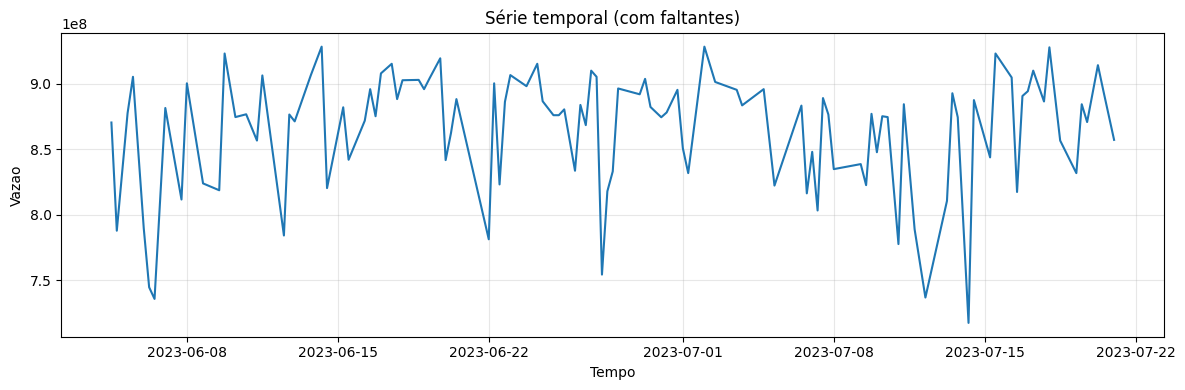

In [41]:
def impute_linear_interpolation(df_missing, col="throughput_bps"):
    df_imputed = df_missing.copy()
    df_imputed[col] = df_imputed[col].interpolate(
        method="linear", limit_direction="both"
    )
    return df_imputed

### TESTING THE FUNCTION ###
df_imputed_linear = impute_linear_interpolation(missing_dfs[0.1].replace(-1, np.nan), col="Vazao")
visualize_time_series(df_imputed_linear, value_col="Vazao")

imputations["Linear_Interpolation"] = df_imputed_linear

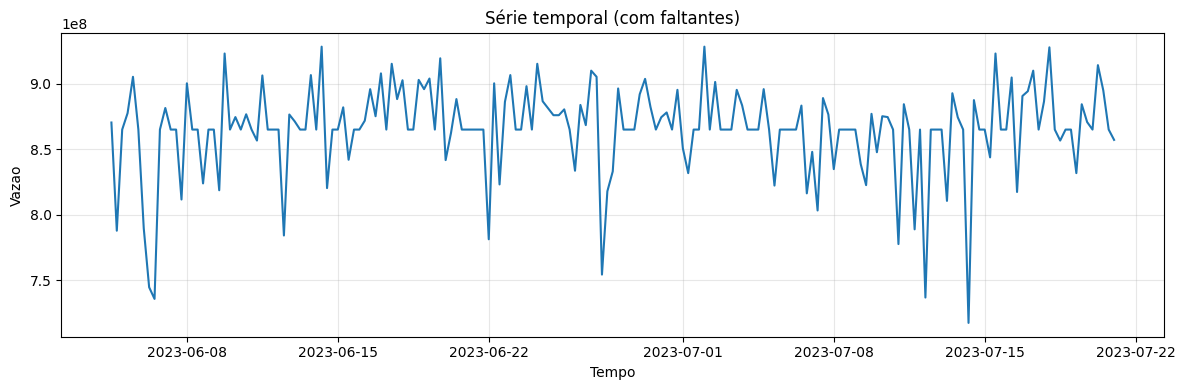

In [42]:
from sklearn.impute import KNNImputer

def impute_knn_imputer(df_missing, k=5, col_value="throughput_bps"):
    df_imp = df_missing.copy()

    imputer = KNNImputer(n_neighbors=k, weights="uniform")
    imputed_values = imputer.fit_transform(df_imp[[col_value]])

    df_imp[col_value] = imputed_values[:, 0]
    return df_imp


### TESTING THE FUNCTION ###
df_imputed_knn = impute_knn_imputer(missing_dfs[0.1].replace(-1, np.nan), k=5, col_value="Vazao")
visualize_time_series(df_imputed_knn, value_col="Vazao")

imputations["KNN_Imputer"] = df_imputed_knn

/tmp/ipykernel_15331/2124410354.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_imp[col_value] = df_imp[col_value].fillna(method="ffill")


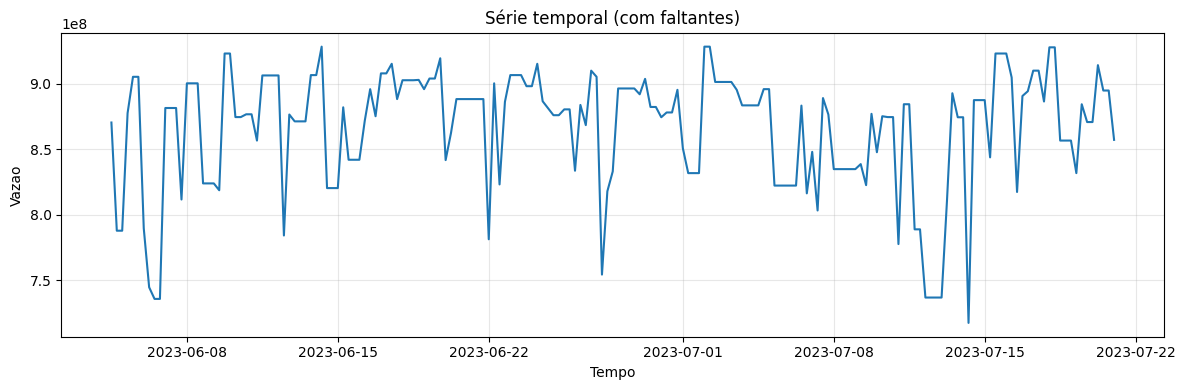

In [43]:
import pandas as pd
import numpy as np

def impute_locf(df_missing, col_value="throughput_bps"):
    """
    Imputa valores faltantes usando LOCF (Last Observation Carried Forward).
    """
    df_imp = df_missing.copy()
    df_imp[col_value] = df_imp[col_value].fillna(method="ffill")
    return df_imp


### TESTANDO A FUNÇÃO ###
df_imputed_locf = impute_locf(
    missing_dfs[0.1].replace(-1, np.nan), 
    col_value="Vazao"
)

visualize_time_series(df_imputed_locf, value_col="Vazao")

imputations["LOCF"] = df_imputed_locf


In [44]:
!pip install scikit-learn

In [45]:
import numpy as np
import pandas as pd

def rmse(a, b):
    diff = np.asarray(a, dtype=float) - np.asarray(b, dtype=float)
    return float(np.sqrt(np.nanmean(diff**2)))

def mae(a, b):
    diff = np.asarray(a, dtype=float) - np.asarray(b, dtype=float)
    return float(np.nanmean(np.abs(diff)))

def compare_imputations(
    df_original: pd.DataFrame | pd.Series,
    df_with_missing: pd.DataFrame | pd.Series,
    imputations: dict,  # {"nome": df_imputed, ...}
    missing_sentinel: float | int = -1,
    columns: list[str] | None = None,
):
    # Series -> DataFrame
    def as_df(x):
        return x.to_frame(name=x.name if x.name else "value") if isinstance(x, pd.Series) else x

    print(f"Original shape: {longest_interval.shape}, Missing shape: {missing_dfs[0.1].shape}")

    if longest_interval.shape != missing_dfs[0.1].shape:
        raise ValueError("DataFrames devem ter a mesma forma (shape).")

    orig = as_df(df_original).copy()
    miss = as_df(df_with_missing).copy()

    if columns is not None:
        missing_cols = [c for c in columns if c in orig.columns]
        if not missing_cols:
            raise ValueError("Nenhuma das 'columns' está presente nos dataframes.")
        orig = orig[missing_cols]
        miss = miss[missing_cols]

    print(f"Original: {orig}, Missing: {miss}")

    # Máscara de faltantes definida pelo sentinel ou NaN
    missing_mask = (miss == missing_sentinel) |  miss.isna()

    print(f"Missing mask:\n{missing_mask}")

    # Para segurança: não avalia onde o original também é NaN
    valid_mask = missing_mask

    print(f"Valid mask:\n{valid_mask}")

    results_rows = []
    per_model_details = {}

    for name, df_imp in imputations.items():
        imp = as_df(df_imp).copy()
        # Alinha com original (índice/colunas)
        imp, _ = imp.align(orig, join="right", axis=None)

        # Garante mesmas colunas
        imp = imp[orig.columns]

        # Calcula métricas por coluna e global (apenas onde valid_mask é True)
        rmse_cols = {}
        mae_cols = {}
        n_points_cols = {}

        for col in orig.columns:
            mask = valid_mask[col].to_numpy()
            if not np.any(mask):
                rmse_cols[col] = np.nan
                mae_cols[col] = np.nan
                n_points_cols[col] = 0
                continue
            y_true = orig[col].to_numpy()[mask]
            y_hat  = imp[col].to_numpy()[mask]
            rmse_cols[col] = rmse(y_true, y_hat)
            mae_cols[col]  = mae(y_true, y_hat)
            n_points_cols[col] = int(mask.sum())

        # Global: concatena todas as colunas válidas
        mask_any = valid_mask.values.flatten()
        y_true_all = orig.values.flatten()[mask_any]
        y_hat_all  = imp.values.flatten()[mask_any]
        rmse_global = rmse(y_true_all, y_hat_all) if y_true_all.size else np.nan
        mae_global  = mae(y_true_all, y_hat_all)  if y_true_all.size else np.nan

        results_rows.append({
            "model": name,
            "rmse_global": rmse_global,
            "mae_global": mae_global,
            "n_pontos_avaliados": int(mask_any.sum())
        })
        per_model_details[name] = {
            "rmse_por_coluna": rmse_cols,
            "mae_por_coluna": mae_cols,
            "n_por_coluna": n_points_cols
        }

    summary = pd.DataFrame(results_rows).sort_values("rmse_global", na_position="last")
    return summary.reset_index(drop=True), per_model_details

summary, details = compare_imputations(
    df_original=longest_interval,  # dados verdadeiros
    df_with_missing=missing_dfs[0.1],  # dados com faltantes (-1)
    imputations=imputations,
    missing_sentinel=-1,
    columns=["Vazao"]  # opcional: avalie só algumas colunas
)

print(summary)          # Tabela com RMSE/MAE globais e n de pontos avaliados

Original shape: (187, 2), Missing shape: (187, 2)
Original:             Vazao
126  8.704948e+08
127  7.877440e+08
128  8.199872e+08
129  8.776594e+08
130  9.054506e+08
..            ...
308  8.853473e+08
309  9.143583e+08
310  8.949596e+08
311  8.708407e+08
312  8.572108e+08

[187 rows x 1 columns], Missing:             Vazao
126  8.704948e+08
127  7.877440e+08
128 -1.000000e+00
129  8.776594e+08
130  9.054506e+08
..            ...
308 -1.000000e+00
309  9.143583e+08
310  8.949596e+08
311 -1.000000e+00
312  8.572108e+08

[187 rows x 1 columns]
Missing mask:
     Vazao
126  False
127  False
128   True
129  False
130  False
..     ...
308   True
309  False
310  False
311   True
312  False

[187 rows x 1 columns]
Valid mask:
     Vazao
126  False
127  False
128   True
129  False
130  False
..     ...
308   True
309  False
310  False
311   True
312  False

[187 rows x 1 columns]
                  model   rmse_global    mae_global  n_pontos_avaliados
0           KNN_Imputer  3.397817e+07  2